# 3. Engagement metrics

### Connecting Google Drive

In [ ]:
# connect GoogleColab with my GoogleDrive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# store prefix path to access all files on my google drive
prefix_path = '/content/drive/My Drive/KeepCoding/DeepLearning/Practica/'

Mounted at /content/drive


### Loading cleaned up data file

In [ ]:
# import Python libraries
import numpy as np
import pandas as pd

# read metadata file
df_clean = pd.read_csv(prefix_path + 'poi_clean.csv', sep=',')
print(f"Size of metadata file: {df_clean.shape[0]} rows and {df_clean.shape[1]} columns.\n")
print(f"Titles of columns: \n {df_clean.columns.tolist()}")

Size of metadata file: 1492 rows and 14 columns.

Titles of columns: 
 ['id', 'name', 'shortDescription', 'categories', 'tier', 'locationLon', 'locationLat', 'tags', 'xps', 'Visits', 'Likes', 'Dislikes', 'Bookmarks', 'main_image_path']


Include categories_counts and tags_counts.

### Quick check to make sure I loaded the correct data set.

I know I changed categories and tags into sets, so I will look for this and also for the last row being number 1491 (giving a total of 1492).

In [ ]:
df_clean.tail(5)

,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
1487,a1058fc5-8b4e-43db-8758-2a4197eb69ca,"Plaza de Puerta Cerrada, en Madrid","ANTONIO ORBEGOZO\nPlaza de Puerta Cerrada, en ...",{'Pintura'},1,-3.707943,40.413677,{'Cruz'},600,10014,8174,63,2150,data_main/a1058fc5-8b4e-43db-8758-2a4197eb69ca...
1488,77df8476-484e-436e-8977-f957f6b9371a,¡Aquel Madrid!,"JUAN ESPLANDIÚ PEÑA\n¡Aquel Madrid!\nABC, núm....",{'Pintura'},1,-3.689120,40.416555,"{'Puerta', 'Parque del Retiro'}",600,10013,679,2963,107,data_main/77df8476-484e-436e-8977-f957f6b9371a...
1489,21c741f5-cbe7-4ae0-a69d-b5c1622056af,El viento se acuesta al atardecer,SERNY (Ricardo Summers e Isern)\nEl viento se ...,{'Pintura'},1,-3.712121,40.419088,"{'Estatuas', 'Plaza'}",600,10005,926,2913,180,data_main/21c741f5-cbe7-4ae0-a69d-b5c1622056af...
1490,4b8b38fa-78b5-4ea8-a676-1de4e2b48caa,Edificio Metrópolis por Herreros,HERREROS (Enrique García-Herreros Codesido)\nS...,{'Pintura'},1,-3.695836,40.418698,"{'Gran Vía', 'Metrópolis', 'Alcalá'}",600,10006,4615,2797,932,data_main/4b8b38fa-78b5-4ea8-a676-1de4e2b48caa...
1491,d7f45b8d-c311-4309-a85a-d91f1fcd3b2f,Monasterio de Moreruela,"Descubre el Monasterio de Moreruela, una joya ...","{'Historia', 'Arquitectura', 'Patrimonio'}",1,-5.777600,41.812321,"{'Monasterio', 'Moreruela', 'Cisterciense', 'R...",500,10011,8623,93,2749,data_main/d7f45b8d-c311-4309-a85a-d91f1fcd3b2f...


In [ ]:
print(type(df_clean['categories'].iloc[0]))


<class 'str'>


In the datafile above, I am missing the categories_count and tags_count features.

I will compute them now, but first I will need to convert them back to sets (when saved to a csv file, they were changed to strings as seen in the code snippet above).

To avoid this problem, I will use pickle whenever I need to save files after splitting files or after preprocessing. (They work better with Python.)

In [ ]:
# convert tags and categories back into sets
# (they were converted to strings when saved to cvs)
# => next time I will save to pickle.
import ast

df_clean['categories'] = df_clean['categories'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_clean['tags'] = df_clean['tags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Now recompute the counts
df_clean['categories_count'] = df_clean['categories'].apply(lambda x: len(x) if isinstance(x, set) else 0)
df_clean['tags_count'] = df_clean['tags'].apply(lambda x: len(x) if isinstance(x, set) else 0)

# Verify
print(df_clean[['categories_count', 'tags_count']].describe())

# add columns 'categories_count' and 'tags_count'
df_clean['categories_count'] = df_clean['categories'].apply(lambda x: len(x) if isinstance(x, set) else 0)
df_clean['tags_count'] = df_clean['tags'].apply(lambda x: len(x) if isinstance(x, set) else 0)

       categories_count   tags_count
count       1492.000000  1492.000000
mean           3.024799     8.920912
std            0.646967     4.275762
min            0.000000     0.000000
25%            3.000000     5.000000
50%            3.000000    10.000000
75%            3.000000    13.000000
max            4.000000    13.000000


##b. Computing engagement variables

In [ ]:
# compute the three signals

# C: Commitment: Bookmarks vs Reactions (= Likes + Dislikes)
df_clean['C'] = df_clean['Bookmarks'] / (df_clean['Likes'] + df_clean['Dislikes'])

# S: Satisfaction: Likes vs Reactions
df_clean['S'] = df_clean['Likes'] / (df_clean['Likes'] + df_clean['Dislikes'])

# V: engagement Volume (modified sigmoid of total interactions)
df_clean['V'] = 2 * (1 / (1 + np.exp(-0.0002 * (df_clean['Bookmarks'] + df_clean['Likes'] + df_clean['Dislikes'])))) - 1


# compute the combined engagement score

# E: engagement score
df_clean['E'] = 0.35 * df_clean['C'] + 0.45 * df_clean['S'] + 0.20 * df_clean['V']

In [ ]:
df_clean[['C', 'S', 'V', 'E']].describe()

,C,S,V,E
count,1492.000000,1492.000000,1492.000000,1492.000000
mean,0.116731,0.461926,0.534802,0.355683
std,0.109551,0.372160,0.210191,0.234379
min,0.011111,0.023435,0.301074,0.084596
25%,0.028628,0.105108,0.365093,0.140704
50%,0.045934,0.241715,0.415384,0.220898
75%,0.179357,0.764572,0.782660,0.526085
max,0.440664,0.994479,0.997117,0.798563


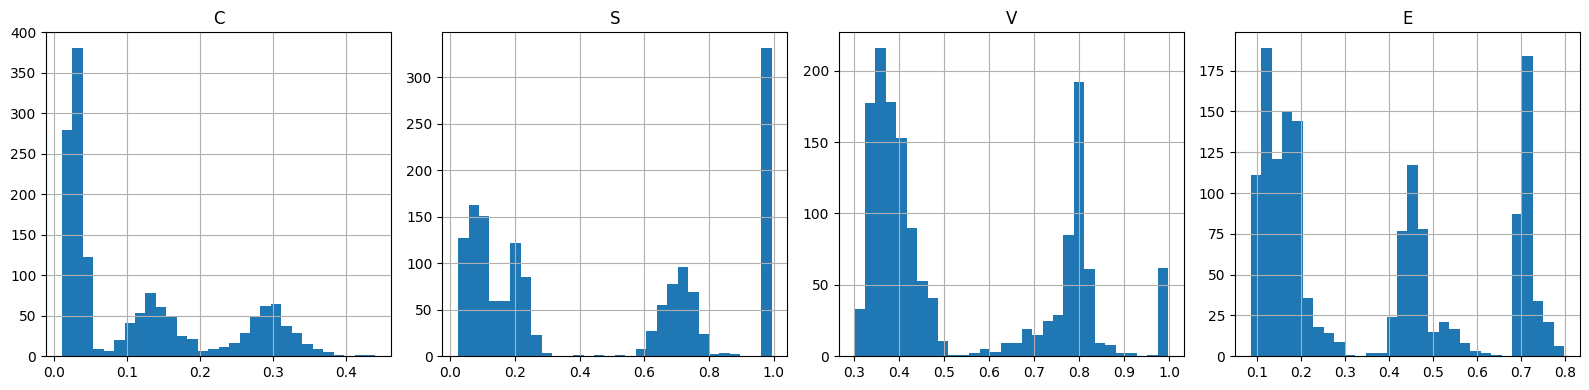

In [ ]:
# Plot distribution for each of the engagement variables

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['C', 'S', 'V', 'E']):
    df_clean[col].hist(bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
# Function to assign to each POI the engagement label
# to use with the tree-based model

threshold_C = 0.20 # good place to separate the two clusters of C

def assign_label(row):
    if row['S'] >= 0.5 and row['C'] < threshold_C:
        return -1  # Good POI, app underrepresents it
    elif row['S'] < 0.5 and row['C'] < threshold_C:
        return 0   # Bad POI, app matches it
    elif row['S'] < 0.5 and row['C'] >= threshold_C:
        return 1   # Bad POI, app oversells it
    else:
        return 2   # Good POI, app does it justice

df_clean['engagement_label'] = df_clean.apply(assign_label, axis=1)
print(df_clean['engagement_label'].value_counts().sort_index())

engagement_label
-1    352
 0    794
 2    346
Name: count, dtype: int64


In [ ]:
# Add multi-hot encoding for 'categories'

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
categories_encoded = mlb.fit_transform(df_clean['categories'])

# Create a dataframe with the encoded categories
categories_df = pd.DataFrame(categories_encoded, columns=mlb.classes_, index=df_clean.index)

# Concatenate to df_clean
df_clean = pd.concat([df_clean, categories_df], axis=1)

# Check
print("Category columns added:", mlb.classes_)
print(df_clean.shape)

Category columns added: ['Arquitectura' 'Ciencia' 'Cine' 'Cultura' 'Escultura' 'Gastronomía'
 'Historia' 'Misterio' 'Naturaleza' 'Ocio' 'Patrimonio' 'Pintura']
(1492, 33)


In [ ]:
# Let's resave this clean dataset to pickle

# Save df_clean
df_clean.to_pickle(prefix_path + 'df_clean.pkl')



---


##e. Splitting dataframe into training/validation and testing

To ensure appropriate balance of the different classes, I will stratify according to 'engagement label'.

Also, I will use a random_state for reproducibility.


In [ ]:
# Split dataset into training/validation and test
# prior to fitting preprocessing to data
# (to prevent any data leakage)

from sklearn.model_selection import train_test_split

# First split: separate test set (15% of total)
df_train_val, df_test = train_test_split(
    df_clean,
    test_size=0.15,
    random_state=42,
    stratify=df_clean['engagement_label']
)

# Second split: 15% of remaining 85% (12.5% of total)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.15,
    random_state=42,
    stratify=df_train_val['engagement_label']
)

# Check sizes
print(f"Train: {len(df_train)} rows ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"Val:   {len(df_val)} rows ({len(df_val)/len(df_clean)*100:.1f}%)")
print(f"Test:  {len(df_test)} rows ({len(df_test)/len(df_clean)*100:.1f}%)")

# Check label distribution across splits
for name, df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f"\n{name} label distribution:")
    print(df['engagement_label'].value_counts().sort_index())

Train: 1077 rows (72.2%)
Val:   191 rows (12.8%)
Test:  224 rows (15.0%)

Train label distribution:
engagement_label
-1    254
 0    573
 2    250
Name: count, dtype: int64

Val label distribution:
engagement_label
-1     45
 0    102
 2     44
Name: count, dtype: int64

Test label distribution:
engagement_label
-1     53
 0    119
 2     52
Name: count, dtype: int64


In [ ]:
# Save splits to pickle
df_train.to_pickle(prefix_path + 'df_train.pkl')
df_val.to_pickle(prefix_path + 'df_val.pkl')
df_test.to_pickle(prefix_path + 'df_test.pkl')